# Chapter 5: Transitioning to Convolutional Neural Networks (CNNs)

**Objective:** To understand the limitations of fully connected neural networks (FCNNs) for image data and introduce the basic concepts of Convolutional Neural Networks (CNNs). This chapter focuses on exploring the architecture and advantages of CNNs.

##  Pre-class Assignments

###  Part 1: Mathematical Challenges

**Task 1: Maximum Step Size Theorem for Gradient Descent on Convex Functions**
- Find the theorem and its proof regarding the "maximum step size for gradient descent on convex functions".
- Provide concrete examples (use specific functions to illustrate the theorem).
- Verify the effect of the theorem on different problems through experiments (complete this in the code cell below).

**Task 2: Relationship Between Data Normalization and Maximum Step Size**
- Analyze: Does normalizing the data affect the maximum step size that can be chosen?
- What is the mathematical relationship between normalization and the maximum step size?
<!-- 
**Task 3: Linear Regression + Proof of Gradient Descent Convergence**
- Define the MSE loss function for linear regression.
- **Proof**: Why is gradient descent guaranteed to converge for linear regression?
- **Quantify Iterations**: If we want the error to be less than $\epsilon$, how many iterations are needed? (Is it $1/\epsilon$ or $1/\epsilon^2$?)
- *(Optional)* Perform the same analysis for Binary Cross Entropy (BCE). -->

---


> **Part 1 Answer Area: Mathematical Challenges**
>
> **Task 1 (Theorem and Proof):**
> - **Theorem**: For an $L$-smooth convex function, gradient descent converges if the step size $\eta$ satisfies $0 < \eta < \frac{2}{L}$.
> - **Proof**: Based on the quadratic upper bound: $f(x_{k+1}) \leq f(x_k) - \eta(1 - \frac{L\eta}{2})\|\nabla f(x_k)\|^2$. To guarantee $f(x_{k+1}) < f(x_k)$, we need $1 - \frac{L\eta}{2} > 0$, hence $\eta < \frac{2}{L}$.
> - **Example**: For $f(x) = x^2$, the second derivative is 2, so $L=2$. Max step size is $\eta < 1$. If $\eta=1$, it oscillates; if $\eta>1$, it diverges.
>
> **Task 2 (Data Normalization):**
> - **Analysis**: Yes, normalization affects the maximum step size.
> - **Mathematical Relationship**: In linear models, the Lipschitz constant $L$ equals the maximum eigenvalue of the data matrix $X^T X$. Normalization scales down the features, reducing $L$. A smaller $L$ allows us to use a larger maximum step size ($\frac{2}{L}$), mapping to faster and more stable convergence.
> 
<!-- > **Task 3 (Linear Regression and Convergence Proof):**
> - **MSE Loss**: $L(w) = \frac{1}{2n}\|Xw - y\|^2$.
> - **Proof**: The Hessian matrix is $\frac{1}{n}X^T X$. Since $X^T X$ is positive semi-definite (eigenvalues $\ge 0$), the MSE loss is a globally convex and smooth function. With a valid step size $\eta < \frac{2}{L}$, gradient descent is strictly guaranteed to roll down to the global minimum.
> - **Quantify Iterations**: For general convex problems, reaching an error $< \epsilon$ takes $\mathcal{O}(1/\epsilon)$ iterations. For strongly convex problems (where $X$ has full rank), it takes $\mathcal{O}(\log(1/\epsilon))$ iterations.
> 
> **Task 3 (Optional: BCE Analysis):**
> - **BCE Loss**: The Hessian of BCE incorporates terms like $p(1-p)$ where $p = \sigma(w^T x)$. Since $p(1-p) \le 0.25$, its Hessian is also positive semi-definite, and $L \le \frac{1}{4}\|X^T X\|$. Thus, BCE is also convex and strictly converges under a proper step size. -->

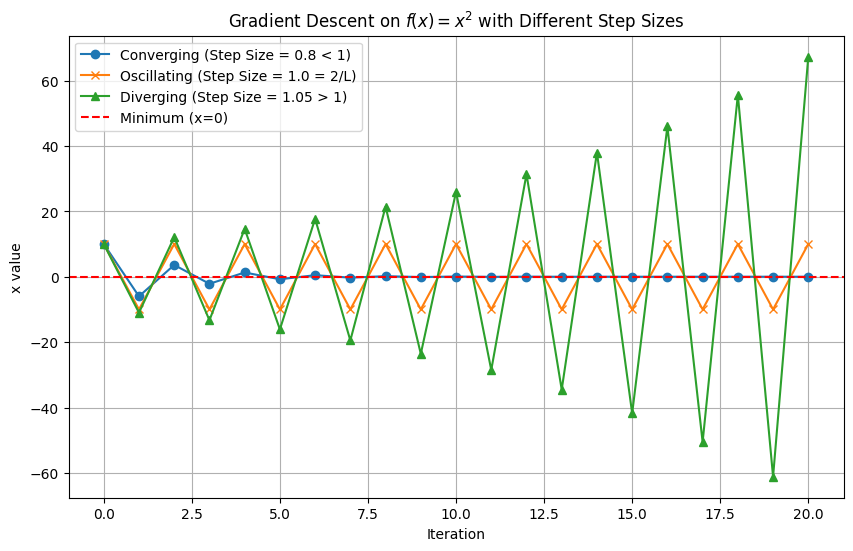

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def convex_function(x):
    # Define the convex function f(x) = x^2
    return x**2


def gradient(x):
    # Gradient f'(x) = 2x
    return 2 * x


def gradient_descent_experiment(initial_x, step_size, max_iters=20):
    x = initial_x
    history = [x]
    for _ in range(max_iters):
        x = x - step_size * gradient(x)
        history.append(x)
    return history


initial_x = 10.0

# L = 2, so 2/L = 1.
# 1. Step size < 1, converges
converging_step = gradient_descent_experiment(initial_x, step_size=0.8)
# 2. Step size = 1, oscillates
oscillating_step = gradient_descent_experiment(initial_x, step_size=1.0)
# 3. Step size > 1, diverges
diverging_step = gradient_descent_experiment(initial_x, step_size=1.05)

plt.figure(figsize=(10, 6))
plt.plot(converging_step, label="Converging (Step Size = 0.8 < 1)", marker='o')
plt.plot(oscillating_step, label="Oscillating (Step Size = 1.0 = 2/L)", marker='x')
plt.plot(diverging_step, label="Diverging (Step Size = 1.05 > 1)", marker='^')

plt.title("Gradient Descent on $f(x)=x^2$ with Different Step Sizes")
plt.xlabel("Iteration")
plt.ylabel("x value")
plt.axhline(0, color='red', linestyle='--', label='Minimum (x=0)')
plt.legend()
plt.grid(True)
plt.show()

## 1. Why Move to Convolutional Neural Networks?

FCNNs treat each pixel independently, ignoring spatial relationships in images. CNNs address this limitation by leveraging spatial structure, making them more effective for image classification tasks.

**Tasks:**
1. Compare FCNNs and CNNs for image classification:
   - How do FCNNs process an image after flattening? What spatial information might be lost?
   - How do CNNs maintain spatial relationships between pixels?
2. Research and list the main advantages of CNNs over FCNNs for image data.

> **Answer:**
> 1. **Comparison:**
>    - **FCNNs:** Flatten 2D images into 1D vectors, destroying the spatial relationships (e.g., up/down, left/right) between adjacent pixels. Local structures like edges and shapes are lost.
>    - **CNNs:** Process images in their original 2D shape. They use sliding filters over small patches of the image, which preserves the local spatial relationships between neighboring pixels.
> 2. **Advantages of CNNs over FCNNs:**
>    - **Parameter Sharing:** The same filter is applied across the entire image, drastically reducing the total number of parameters and preventing overfitting.
>    - **Translation Invariance:** Can detect features (like an eye or edge) no matter where they appear in the image.
>    - **Preserves 2D Spatial Structure:** Understands local pixel neighborhoods, which is essential for visual data.

## 2. Key Components of CNNs

CNNs consist of specialized layers designed to process image data efficiently.

### 2.1 Convolutional Layers

Convolutional layers apply filters (small matrices) to input images to extract features such as edges, textures, and shapes.

**Tasks:**
1. Research how convolutional filters work. What is the purpose of sliding a filter across an image?
2. What is a **feature map**? Why does its size depend on filter size, stride, and padding?

**Questions to Explore:**
- What features might the first convolutional layer detect compared to deeper layers?
- Why do CNNs use multiple filters in each layer?

> **Answer:**
> 1. **How filters work:** Filters are small matrices of learnable weights. Sliding them across the image computes element-wise dot products, allowing the network to detect local patterns regardless of their position.
> 2. **Feature map:** It is the 2D output array produced by the convolution operation. Its size changes based on the filter dimension (larger reduces output size), stride (larger steps reduce size), and padding (adding borders preserves size).
> 3. **Early vs Deep features:** Early layers detect simple low-level features like edges, lines, or colors. Deeper layers combine these basic patterns to detect complex, high-level features like shapes, animal parts, or faces.
> 4. **Multiple filters:** A single filter can only detect one specific pattern (e.g., a vertical edge). Using multiple filters allows the layer to extract a rich variety of different features simultaneously.

### 2.2 Pooling Layers

Pooling layers down-sample feature maps, reducing size while retaining key information. The most common type is **max pooling**.

**Tasks:**
1. Research the difference between max pooling and average pooling.
2. Why is down-sampling important? How might it help with overfitting?

**Questions to Explore:**
- What is the effect of pooling on computational efficiency?
- Could pooling layers cause a loss of information? Why or why not?

> **Answer:**
> 1. **Max vs. Average Pooling:** Max pooling selects the largest value in a window, highlighting the most prominent features (e.g., edges or textures). Average pooling calculates the mean, which smooths the features and retains background information.
> 2. **Down-sampling & Overfitting:** It reduces the spatial dimensions of feature maps. This prevents the network from memorizing exact pixel locations (adding spatial invariance), acting as a form of regularization that reduces overfitting.
> 3. **Computational Efficiency:** By shrinking the width and height of the feature maps (e.g., halving them reduces data by 75%), it drastically decreases the number of parameters and computational cost in subsequent layers.
> 4. **Information Loss:** Yes, pooling inherently discards precise spatial details and non-maximal/local values. However, this is largely intentional—losing exact pixel coordinates makes the network robust to small shifts, distortions, and noise.

### 2.3 Fully Connected Layers in CNNs

CNNs usually end with fully connected layers to combine extracted features and make final predictions.

**Tasks:**
1. Why do CNNs still need fully connected layers for classification?
2. How does the input to fully connected layers differ from the input to convolutional layers?

> **Answer:**
> 1. **Why FC layers are needed:** While convolutional layers are excellent at extracting local spatial features (like edges and shapes), fully connected layers are needed to synthesize all these distinct features globally. They act as the final classifier, mapping the extracted features to final class probabilities.
> 2. **Input differences:** Convolutional layers accept 2D or 3D tensors (images or feature maps with height, width, and depth/channels), which preserves spatial geometry. In contrast, fully connected layers only accept 1D flat vectors, so the extracted spatial features must be "flattened" into a single array before processing.

## 3. CNN Architecture Basics

A basic CNN for image classification might look like this:
1. Convolutional Layer: Extracts features from the image.
2. Pooling Layer: Reduces feature map dimensions.
3. Convolutional Layer: Extracts more complex features.
4. Pooling Layer: Further reduces feature map dimensions.
5. Flatten Layer: Converts feature maps into a vector.
6. Fully Connected Layers: Make the final classification.

**Tasks:**
1. Design a simple CNN architecture for CIFAR-10:
   - How many convolutional and pooling layers should you include?
   - How many filters will each convolutional layer use?
   - What activation function should you use in the convolutional layers?
2. Sketch your architecture and label the data dimensions at each layer.

> **Answer:**
> 1. **Architecture Design for CIFAR-10:**
>    - **Layers:** 2 Convolutional layers and 2 Max-Pooling layers.
>    - **Filters:** 32 filters in the first convolutional layer, and 64 filters in the second layer. (Filter size: $3 \times 3$).
>    - **Activation:** **ReLU** for all convolutional layers and hidden fully connected layers to introduce non-linearity.
> 
> 2. **Architecture Sketch & Dimensions (assuming 'same' padding for Conv):**
>    - **Input Image:** $32 \times 32 \times 3$
>    - **Conv Layer 1 (32 filters):** $32 \times 32 \times 32$
>    - **Pooling Layer 1 ($2 \times 2$):** $16 \times 16 \times 32$
>    - **Conv Layer 2 (64 filters):** $16 \times 16 \times 64$
>    - **Pooling Layer 2 ($2 \times 2$):** $8 \times 8 \times 64$
>    - **Flatten Layer:** $8 \times 8 \times 64 = 4096$ (1D vector)
>    - **Fully Connected (Dense) Layer:** 128 neurons
>    - **Output Layer:** 10 neurons (with Softmax for 10 classes)

## 4. Build Your First CNN (Programming Assignment)

**Tasks:**
1. Define a CNN architecture using **TensorFlow/Keras Sequential API**.
2. Include at least:
   - One convolutional layer with ReLU activation.
   - One pooling layer.
   - A fully connected layer with softmax activation.
3. Compile the model with the same loss function and optimizer used in Session 3.

**Architecture Code Explanation:**

*   `Sequential([...])`: This container runs layers in order, like an assembly line from input to final prediction.
*   `Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3))`:
    *   `32`: Number of filters (how many different patterns the layer can detect).
    *   `(3, 3)`: Kernel size (the sliding window size).
    *   `activation='relu'`: Applies ReLU after convolution to add non-linearity.
    *   `input_shape=(32, 32, 3)`: Input format = height, width, color channels (RGB).
*   `MaxPooling2D(pool_size=(2, 2))`:
    *   `pool_size=(2, 2)`: For each 2x2 region, keep the maximum value to reduce size and computation.
*   `Flatten()`: Converts 3D feature maps into a 1D vector for dense layers.
*   `Dense(128, activation='relu')`:
    *   `128`: Number of neurons in the hidden fully connected layer.
    *   `activation='relu'`: Adds non-linearity for stronger feature combination.
*   `Dense(10, activation='softmax')`:
    *   `10`: Number of output classes.
    *   `activation='softmax'`: Converts scores into class probabilities that sum to 1.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Load and preprocess the CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Define a function to build the model, so we can generate a fresh model each time


def build_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model


# 2. Define the hyperparameters you want to test
# Here we compare three groups: different Batch Sizes and Learning Rates
hyperparameters = {
    "Config A (large BS)":    {"lr": 0.001,  "batch_size": 1024},
    "Config B (Small BS)": {"lr": 0.0001,   "batch_size": 128},
    "Config C (Base)": {"lr": 0.001,  "batch_size": 256}
}

epochs = 75  # Run 75 epochs uniformly
histories = {}

# 3. Loop through and train each hyperparameter configuration
print("\n=== Start hyperparameter comparison experiment ===")
for name, params in hyperparameters.items():
    print(f"\n--- Training {name} ---")
    print(
        f"Hyperparameters: Learning Rate={params['lr']}, Batch Size={params['batch_size']}")

    model = build_model()
    # Customize the optimizer for the current configuration
    optimizer = Adam(learning_rate=params['lr'])
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Start training and save the history data
    history = model.fit(x_train, y_train,
                        epochs=epochs,
                        batch_size=params['batch_size'],
                        validation_data=(x_test, y_test),
                        verbose=1)  # verbose=1 shows the training progress bar
    histories[name] = history

print('\n=== All models finished training, please run the next cell to see the comparison charts ===')

In [ ]:
import matplotlib.pyplot as plt

# 4. Visualize and compare training results (read data from the histories dictionary)
plt.figure(figsize=(16, 6))

color_map = {
    "Config A (large BS)": "blue",
    "Config B (Small BS)": "green",
    "Config C (Base)": "red"
}

# Plot Accuracy comparison
plt.subplot(1, 2, 1)
for name, history in histories.items():
    # Plot Validation set: solid line + dot
    plt.plot(history.history['val_accuracy'], label=f'{name} - Val',
             color=color_map[name], marker='o', markersize=4, linestyle='-')
    # Plot Training set: dashed line
    plt.plot(history.history['accuracy'], label=f'{name} - Train',
             color=color_map[name], linestyle='--', alpha=0.5)

plt.title('Accuracy Comparison (Train vs Val)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss comparison
plt.subplot(1, 2, 2)
for name, history in histories.items():
    # Plot Validation set: solid line + cross
    plt.plot(history.history['val_loss'], label=f'{name} - Val',
             color=color_map[name], marker='x', markersize=4, linestyle='-')
    # Plot Training set: dashed line
    plt.plot(history.history['loss'], label=f'{name} - Train',
             color=color_map[name], linestyle='--', alpha=0.5)

plt.title('Loss Comparison (Train vs Val)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

<img src="output.png" width="1000" alt="Accuracy and Loss Comparison">

## 5. Reflection

After defining your CNN, reflect on the following questions.

**Questions to Reflect On:**
1. How does the number of parameters in your CNN compare to your FCNN from Chapter 3? Why are CNNs typically more efficient?
2. What challenges did you face when deciding the architecture?
3. What improvements might you make to your CNN in future iterations?

> **Answer:**
> 1. **Parameter Comparison & Efficiency:** The CNN has significantly fewer parameters. An FCNN connects every single image pixel to every neuron, leading to huge parameter counts. CNNs are highly efficient because they use **parameter sharing** (small filters slide across the whole image, reusing the same weights) and intermediate pooling layers to iteratively reduce data size.
> 2. **Architecture Challenges:** The main challenges are balancing complexity to prevent overfitting and keeping track of shrinking feature map dimensions after consecutive Convolutional and Pooling layers. Tuning hyperparameters like Learning Rate and Batch Size requires extensive trial and error.
> 3. **Future Improvements:** 
>    - Add **Dropout** layers or **Batch Normalization** to reduce overfitting and speed up training.
>    - Use **Data Augmentation** (e.g., random flipping or shifting) to artificially expand the training dataset.
>    - Design a deeper network (more Conv layers) or use pre-trained state-of-the-art architectures (Transfer Learning).